In [19]:
import pickle
import os
import sys
import seaborn as sns

import numpy as np
from matplotlib import pyplot as plt

# Monkey-patch missing numpy internal path
sys.modules['numpy._core.numeric'] = np.core.numeric



In [10]:
result_dir = '../results'

In [34]:
dataset = 'natural'

In [35]:
theory_performance_path = os.path.join(result_dir, f'NGTU[{dataset}]performance.pkl')
actual_performance_path = os.path.join(result_dir, f'NGTU1[{dataset}]performance.pkl')

random_performance_path = os.path.join(result_dir, f'NGTU1[{dataset}_RANDOM]performance.pkl')

with open(theory_performance_path, 'rb') as file:
    theory_dict = pickle.load(file)
    
    
with open(actual_performance_path, 'rb') as file:
    actual_dict = pickle.load(file)
    
with open(random_performance_path, 'rb') as file:
    random_dict = pickle.load(file)

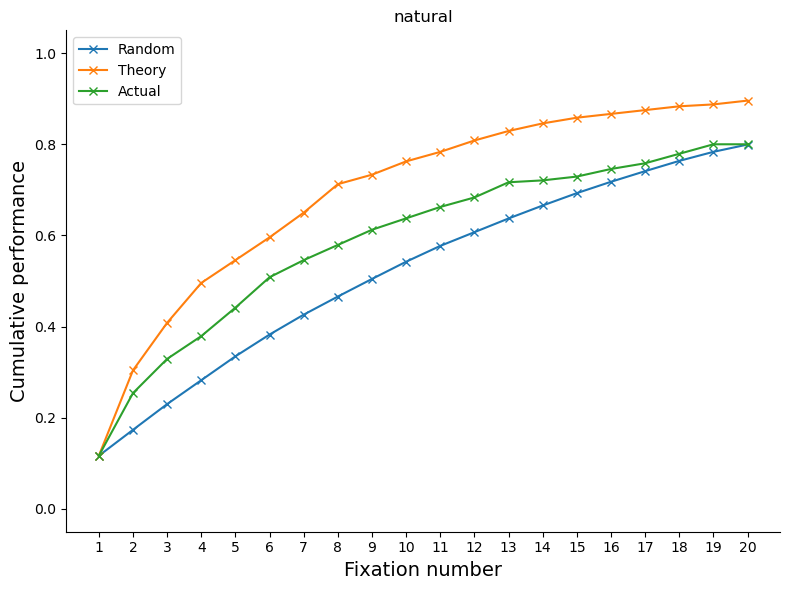

In [36]:
labels = ['Random', 'Theory', 'Actual']
avg_cdfs = [random_dict['TCT'], theory_dict['TCT'], actual_dict['TCT']]


plt.figure(figsize=(8, 6), dpi=100)

for mean, label in zip(avg_cdfs, labels):
    plt.plot(np.arange(1, 21), mean, label=label, marker='x')

plt.xticks(range(1, 21))
plt.ylim([-0.05, 1.05])
plt.legend()
plt.xlabel('Fixation number', fontsize=14)
plt.ylabel('Cumulative performance', fontsize=14)
plt.title(dataset)
plt.legend(loc=2)
sns.despine()
plt.tight_layout()